KNN Classification


In [3]:
from pandas import read_csv
import numpy as np
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier

In [4]:
# importing the dataset
filename = '/Users/furkhanansari/Desktop/Data Science/DataSets/pima-indians-diabetes.data.csv'
name = [
    'preg' , 'plas' , 'pres' ,'skin' , 'test', 'mass','pedi' , 'age','class'
]
dataframe = read_csv(filename , names = name)

#model
array = dataframe.values
X = array[:,0:8]
Y = array[:,8]
num_folds = 10
kfold = KFold(n_splits =10)

model = KNeighborsClassifier(n_neighbors =17)
results = cross_val_score(model , X , Y ,cv =kfold)

print(results.mean())

0.7565276828434724


Grid Search for Algorithm Tuning:

In [5]:
# grid search for algo tuning
import numpy 
from pandas import read_csv
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV


In [6]:
# importing the dataset
filename = '/Users/furkhanansari/Desktop/Data Science/DataSets/pima-indians-diabetes.data.csv'
name = [
    'preg' , 'plas' , 'pres' ,'skin' , 'test', 'mass','pedi' , 'age','class'
]
dataframe = read_csv(filename , names = name)

#model
array = dataframe.values
X = array[:,0:8]
Y = array[:,8]

In [7]:
n_neighbors = numpy.array(range(1,40))
param_grid = dict(n_neighbors  = n_neighbors)

In [11]:
model = KNeighborsClassifier()
grid = GridSearchCV(estimator = model , param_grid = param_grid)
grid.fit(X,Y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': array([ 1, 2..., 37, 38, 39])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: int, default=0Controls the verbosity of information printed during fi

In [12]:
print(grid.best_score_)
print(grid.best_params_)

0.7578558696205755
{'n_neighbors': np.int64(14)}


Visualizing the CV results


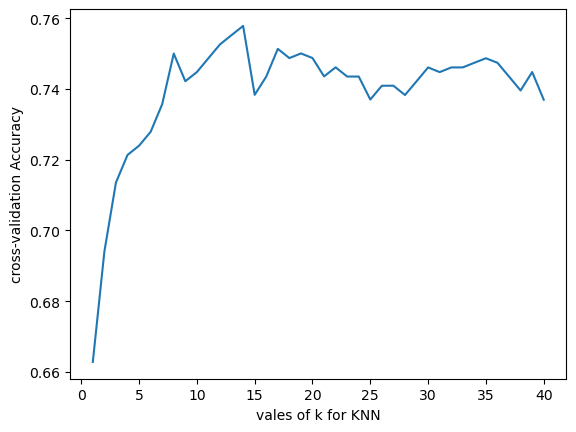

In [17]:
import matplotlib.pyplot as plt
%matplotlib inline
# choose k between 1 to 41
k_range = range (1,41)
k_score = []
# use iteration to calculator difference  k in models , then return the average accuracy based on the cross validation
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn,X,Y,cv=5)
    k_score.append(scores.mean())
# plot to see clearly
plt.plot(k_range,k_score)
plt.xlabel('vales of k for KNN')
plt.ylabel('cross-validation Accuracy')
plt.show()